# KASE Stock Price Movement Classification - 5 Trading Days Horizon

## Project Goal
The goal of this project is to build a classification model that predicts the **future direction of price movement** for a liquid stock traded on **KASE (Kazakhstan Stock Exchange)**.

We use **historical market data (≈ 1 year)** such as OHLCV (Open, High, Low, Close, Volume) to predict whether the stock price will go:
- **Up (1)**,  
- **Down (-1)**
within the next **5 trading days**.

## Why this is relevant
Predicting short-term price direction is a common applied task in financial analytics.  
Even simple classification baselines (Logistic Regression, SVM, Random Forest, etc.) can demonstrate:
- data collection skills (web scraping / API-style scraping),
- preprocessing and feature engineering,
- model training & evaluation.

## Part I - Data Collection (Scraping KASE)
In this section we programmatically download historical OHLCV data for a set of liquid KASE tickers using KASE TV-charts endpoint and store it locally for further analysis.

In [2]:
import time
import requests
import pandas as pd
from pathlib import Path

from matplotlib import pyplot as plt

## 1) KASE endpoint and tickers

We use KASE TV-charts API endpoint:

`https://kase.kz/tv-charts/securities/history`

Then we define:
- request headers,
- the list of tickers,
- and a function to download historical candles.

In [3]:
BASE_URL = "https://kase.kz/tv-charts/securities/history"

HEADERS = {
    "Accept": "*/*",
    "Referer": "https://kase.kz/",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/143.0.0.0 Safari/537.36",
}

TICKERS = [
    "AIRA", "CCBN", "HSBK", "KCEL", "KEGC",
    "KMGZ", "KSPI", "KZAP", "KZTK", "KZTO",
]

## 2) Download historical data (daily candles)

We download approximately 1 year of daily candles using:
- `resolution="1D"`

The function returns a DataFrame with:
- date, open, high, low, close, volume, ticker

If the endpoint returns non-ok status, we return an empty DataFrame.

In [4]:
def fetch_kase_history(ticker: str, days: int = 365, resolution: str = "1D") -> pd.DataFrame:
    now = int(time.time())
    frm = now - days * 24 * 60 * 60

    params = {
        "symbol": f"ALL:{ticker}",
        "resolution": resolution,
        "from": frm,
        "to": now,
        "chart_language_code": "ru",
    }

    r = requests.get(BASE_URL, params=params, headers=HEADERS, timeout=30)
    r.raise_for_status()
    data = r.json()

    if data.get("s") != "ok":
        return pd.DataFrame()

    df = pd.DataFrame({
        "date": pd.to_datetime(data["t"], unit="s"),
        "open": data["o"],
        "high": data["h"],
        "low": data["l"],
        "close": data["c"],
        "volume": data.get("v", [None] * len(data["t"])),
    })

    df["ticker"] = ticker
    df = df.sort_values("date").reset_index(drop=True)

    return df

## 3) Create classification target for 5 trading days ahead

Our prediction target is the **direction of price movement** over the next 5 trading days:

- If future close > current close → label = 1  
- If future close < current close → label = -1  
- If equal (rare) → label = 0  

This aligns with the project statement: predicting direction within a 5-day horizon.

In [5]:
def add_future_direction_label(df: pd.DataFrame, horizon: int = 5) -> pd.DataFrame:
    df = df.copy()
    df["future_close"] = df["close"].shift(-horizon)
    df["future_delta"] = df["future_close"] - df["close"]
    df["target_direction_5d"] = df["future_delta"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    df = df.dropna(subset=["future_close"]).reset_index(drop=True)
    return df

## 4) Download data for all tickers and save to CSV

We save:
- a per-ticker dataset,
- a combined dataset containing all tickers.

These saved files will be used later for:
- cleaning,
- feature engineering,
- model training and evaluation.

In [6]:
out_dir = Path("kase_data")
out_dir.mkdir(exist_ok=True)

all_dfs = []
summary_rows = []

for t in TICKERS:
    df_t = fetch_kase_history(t, days=365, resolution="1D")
    if df_t.empty:
        print(f"[WARN] {t}: no data")
        continue

    df_t = add_future_direction_label(df_t, horizon=5)

    df_t.to_csv(out_dir / f"{t}_1y_1D_h5.csv", index=False, encoding="utf-8")
    all_dfs.append(df_t)

    summary_rows.append({
        "ticker": t,
        "rows": len(df_t),
        "traded_days": int((df_t["volume"].fillna(0) > 0).sum()),
        "volume_sum": float(df_t["volume"].fillna(0).sum()),
        "up_days": int((df_t["target_direction_5d"] == 1).sum()),
        "down_days": int((df_t["target_direction_5d"] == -1).sum())
    })

    print(f"[OK] {t}: {len(df_t)} rows")

combined = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
summary = pd.DataFrame(summary_rows).sort_values("volume_sum", ascending=False) if summary_rows else pd.DataFrame()

if not combined.empty:
    combined.to_csv(out_dir / "ALL_TICKERS_1y_1D_h5.csv", index=False, encoding="utf-8")

if not summary.empty:
    summary.to_csv(out_dir / "LIQUIDITY_RANK_1y_1D_h5.csv", index=False, encoding="utf-8")

combined.shape, summary.head(10)

[OK] AIRA: 242 rows
[OK] CCBN: 242 rows
[OK] HSBK: 242 rows
[OK] KCEL: 242 rows
[OK] KEGC: 242 rows
[OK] KMGZ: 242 rows
[OK] KSPI: 242 rows
[OK] KZAP: 242 rows
[OK] KZTK: 242 rows
[OK] KZTO: 242 rows


((2420, 10),
   ticker  rows  traded_days    volume_sum  up_days  down_days
 2   HSBK   242          242  5.094899e+10      135        106
 8   KZTK   242          242  3.271725e+10      134        108
 1   CCBN   242          242  2.758634e+10      133        108
 5   KMGZ   242          242  2.524251e+10      128        114
 7   KZAP   242          242  2.223188e+10      141        101
 3   KCEL   242          242  1.956518e+10      106        135
 0   AIRA   242          242  1.650393e+10      118        124
 6   KSPI   242          242  1.449116e+10       90        151
 9   KZTO   242          242  1.140754e+10      140        100
 4   KEGC   242          242  1.017355e+10      110        127)

## 5) Quick sanity check

We load one saved ticker dataset and preview the first rows.
This confirms that:
- data was downloaded,
- target label was created,
- CSV structure is correct for the next steps.

In [7]:
example_path = "kase_data/CCBN_1y_1D_h5.csv"
df_example = pd.read_csv(example_path)
df_example.head()

,date,open,high,low,close,volume,ticker,future_close,future_delta,target_direction_5d
0,2024-12-26,2148.00,2154.89,2138.0,2143.00,44207336.0,CCBN,2292.10,149.10,1
1,2024-12-27,2150.00,2197.00,2141.6,2179.00,41225964.0,CCBN,2397.89,218.89,1
2,2024-12-30,2179.00,2273.00,2170.0,2190.86,62849831.0,CCBN,2452.01,261.15,1
3,2024-12-31,2163.00,2227.00,2150.0,2186.99,37827718.0,CCBN,2541.00,354.01,1
4,2025-01-05,2186.99,2249.96,2185.0,2210.95,17989556.0,CCBN,2549.99,339.04,1


## Part II - Exploratory Data Analysis (EDA)

Before building any machine learning model, it is important to understand the behavior of the market data.
In this section, we explore historical price and volume dynamics of a liquid KASE stock.

For each visualization, we focus on two questions:
- What do we observe?
- Why is this information important for predicting future price direction?

### 2.1 Closing Price Over Time

We start by analyzing how the closing price changes over time.
This helps us understand the overall trend, volatility, and major market movements.

Understanding price dynamics is crucial because our classification target
is based on future price movement.

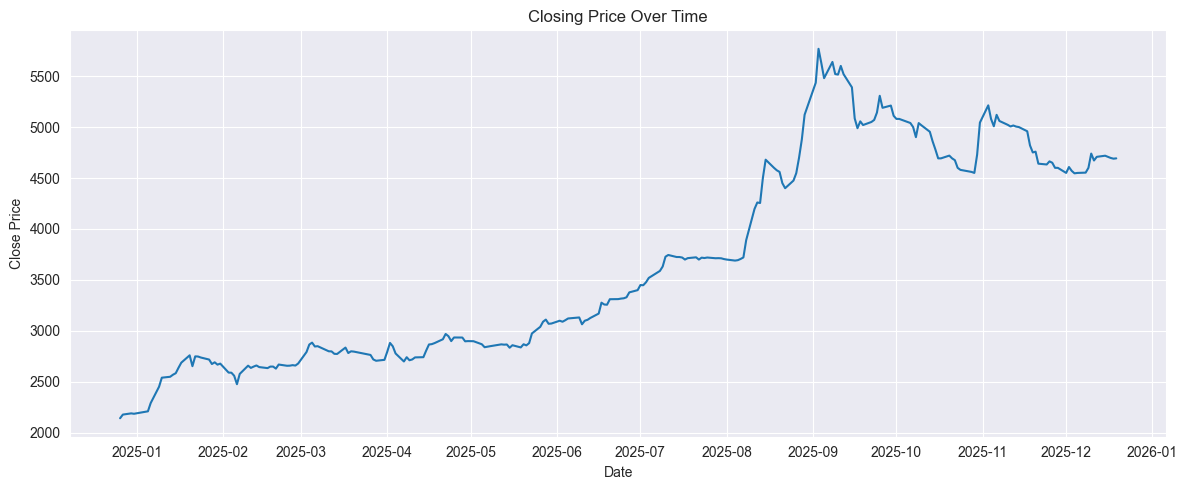

In [9]:
import matplotlib.dates as mdates

df_example["date"] = pd.to_datetime(df_example["date"])

plt.figure(figsize=(12, 5))
plt.plot(df_example["date"], df_example["close"])

plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.grid(True)
plt.tight_layout()
plt.show()

### 2.2 Trading volume over time

We can see how trading activity (volume) changes over time.  
Volume often reflects market interest and liquidity. Sudden spikes may indicate news, increased volatility, or abnormal trading activity.

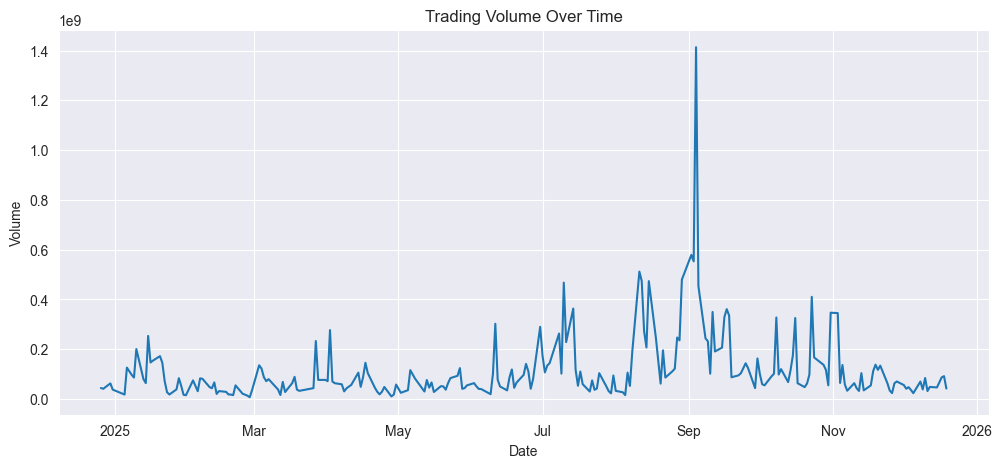

In [10]:
df_plot = df_example.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])
df_plot = df_plot.sort_values("date")

plt.figure(figsize=(12, 5))
plt.plot(df_plot["date"], df_plot["volume"])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

plt.show()

### 2.3 Distribution of daily returns

We're looking at distribution of daily price returns (percent change).  
Returns distribution shows volatility, skewness, and the presence of extreme moves (outliers), which impacts model stability.

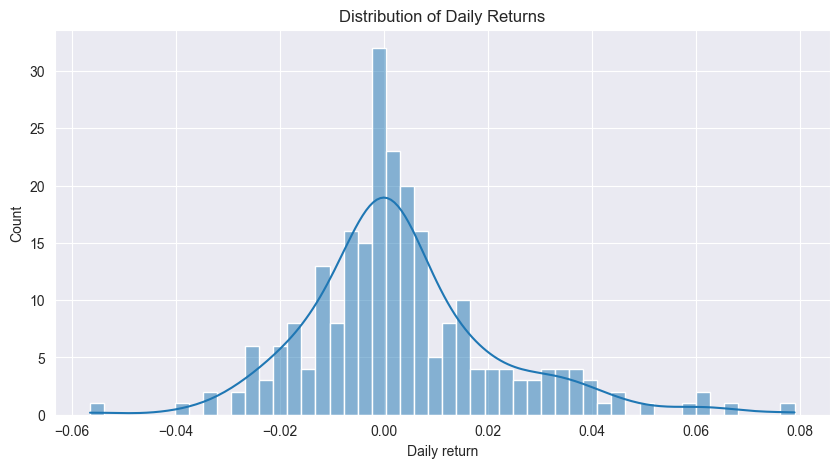

count    241.000000
mean       0.003428
std        0.018598
min       -0.056586
25%       -0.006013
50%        0.000642
75%        0.010956
max        0.078923
Name: daily_return, dtype: float64

In [11]:
import numpy as np
import seaborn as sns

df_plot = df_example.copy()
df_plot["date"] = pd.to_datetime(df_plot["date"])
df_plot = df_plot.sort_values("date")

df_plot["daily_return"] = df_plot["close"].pct_change()

plt.figure(figsize=(10, 5))
sns.histplot(df_plot["daily_return"].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily return")
plt.ylabel("Count")
plt.grid(True)
plt.show()

df_plot["daily_return"].describe()

### 2.4 Target Class Distribution

We analyze the distribution of the target variable `target_direction_5d`,
which indicates whether the price increased or decreased over the next 5 days.

Class balance is important because highly imbalanced classes
can negatively affect classification model performance.

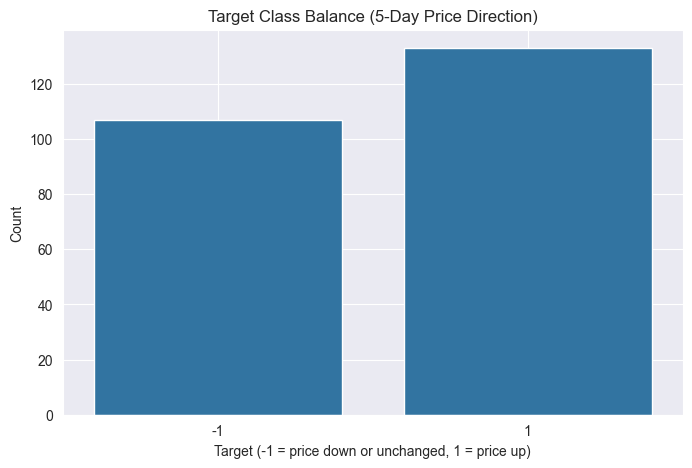

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot( x="target_direction_5d", data=df_example, order=[-1, 1] )
plt.title("Target Class Balance (5-Day Price Direction)")
plt.xlabel("Target (-1 = price down or unchanged, 1 = price up)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

### 2.5 Volume vs future price direction

Whether volume differs depending on future 5-day direction.  
Higher volume may be associated with stronger trend continuation or higher uncertainty; this can provide predictive signal.

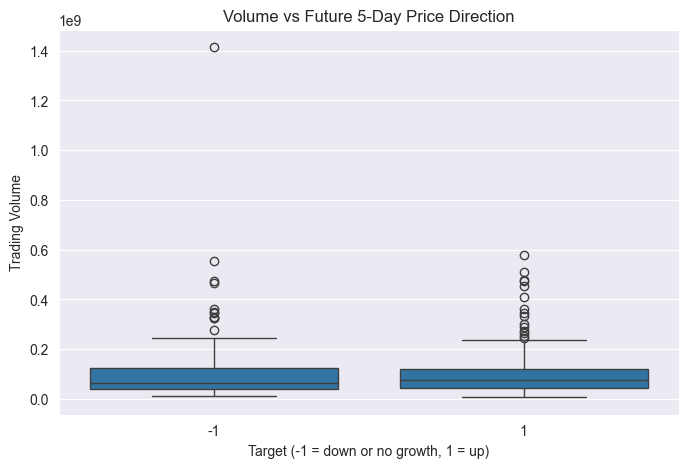

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="target_direction_5d",
    y="volume",
    data=df_example,
    order=[-1, 1]
)
plt.title("Volume vs Future 5-Day Price Direction")
plt.xlabel("Target (-1 = down or no growth, 1 = up)")
plt.ylabel("Trading Volume")
plt.show()

### 2.6 Price range (High–Low) over time

We're looking at daily trading range (High − Low) over time.  
Range is a simple volatility proxy. Higher ranges often mean more uncertainty and can affect model behavior.

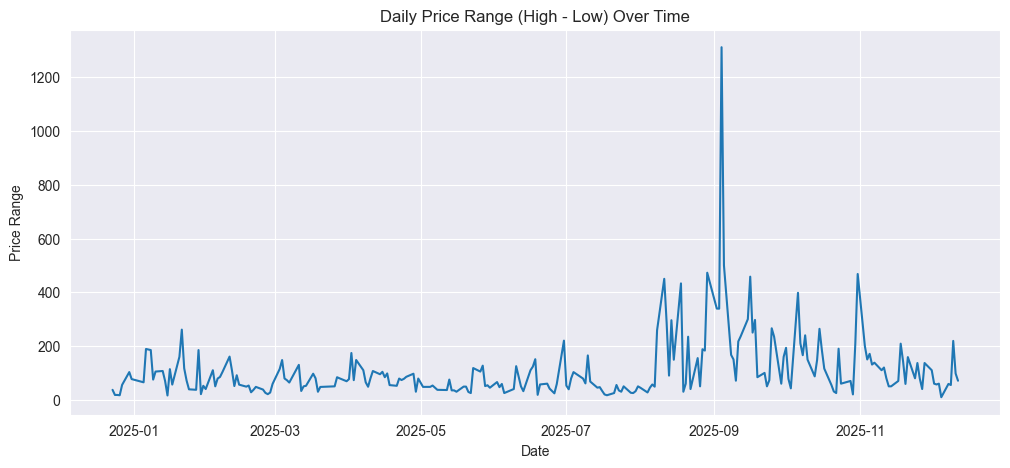

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df_example["date"], df_example["high"] - df_example["low"])
plt.title("Daily Price Range (High - Low) Over Time")
plt.xlabel("Date")
plt.ylabel("Price Range")
plt.grid(True)
plt.show()

### 2.6 Correlation heatmap (numerical features)

We can see correlations between numerical variables (OHLC, volume, engineered features).  
Strong correlations may indicate redundant features and can also show which variables move together with the target-related signals.

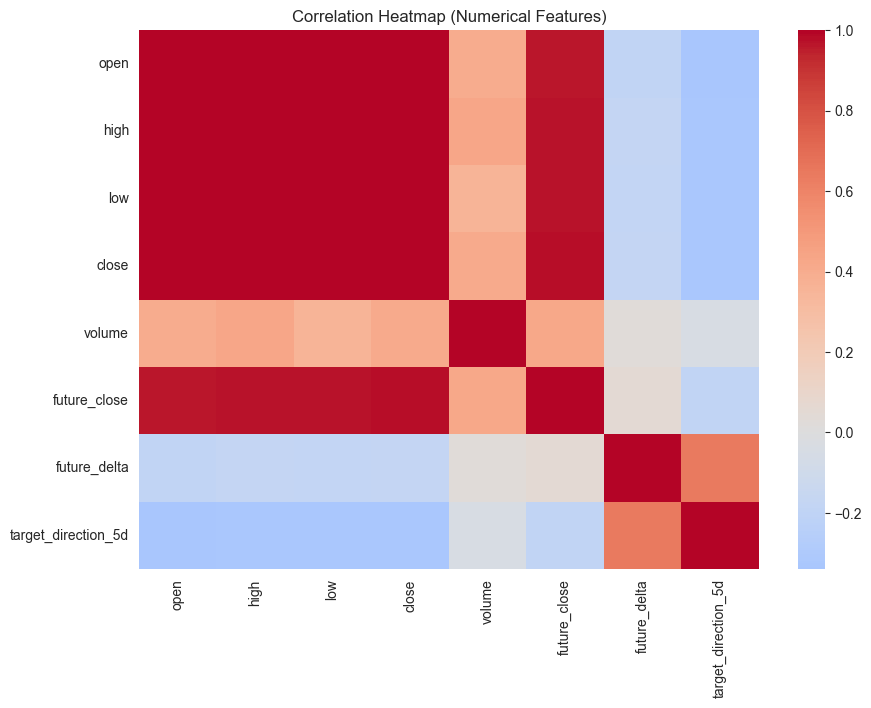

In [24]:
df_plot = df_example.copy()

numeric_cols = df_plot.select_dtypes(include=["int64", "float64"]).columns.tolist()

corr = df_plot[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

### 2.8 Daily Returns vs Future Price Direction

This visualization compares the distribution of daily returns
depending on the future 5-day price direction.

Returns reflect short-term momentum and volatility.
Differences in distributions may indicate whether recent price behavior
contains predictive information about future direction.

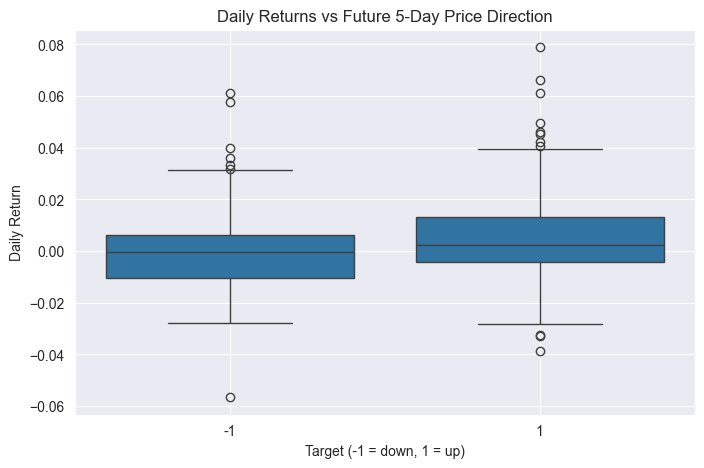

In [12]:
df_returns = df_example.copy()
df_returns["daily_return"] = df_returns["close"].pct_change()

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="target_direction_5d",
    y="daily_return",
    data=df_returns,
    order=[-1, 1]
)
plt.title("Daily Returns vs Future 5-Day Price Direction")
plt.xlabel("Target (-1 = down, 1 = up)")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

### 2.9 Rolling Volatility Over Time

Rolling volatility captures changes in market uncertainty over time.
Periods of high volatility often precede strong trends or reversals,
which makes volatility an important feature for price direction classification.

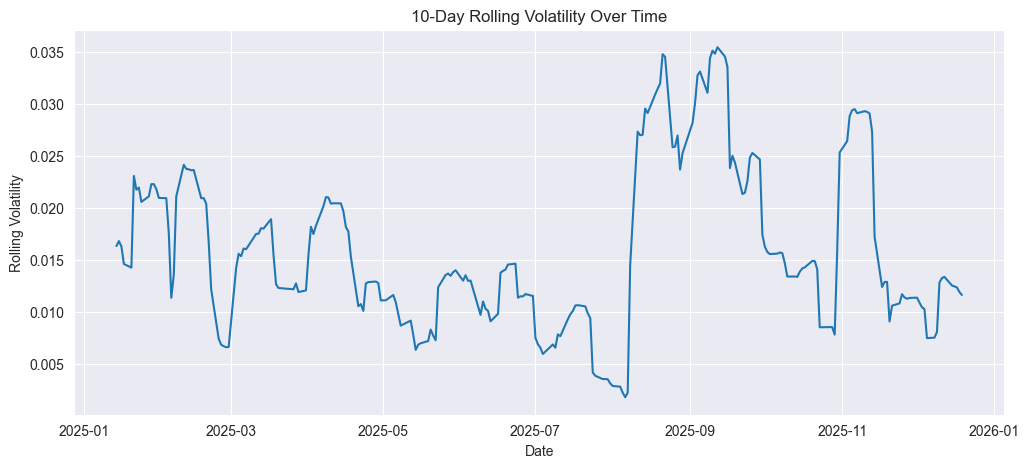

In [13]:
df_vol = df_example.copy()
df_vol["daily_return"] = df_vol["close"].pct_change()
df_vol["rolling_volatility_10d"] = df_vol["daily_return"].rolling(10).std()

plt.figure(figsize=(12, 5))
plt.plot(df_vol["date"], df_vol["rolling_volatility_10d"])
plt.title("10-Day Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True)
plt.show()

### 2.10 Volume vs Daily Price Range

This scatter plot shows the relationship between trading volume
and daily price range (High - Low).
Large ranges combined with high volume often indicate strong market activity,
which may carry information about future price movements.

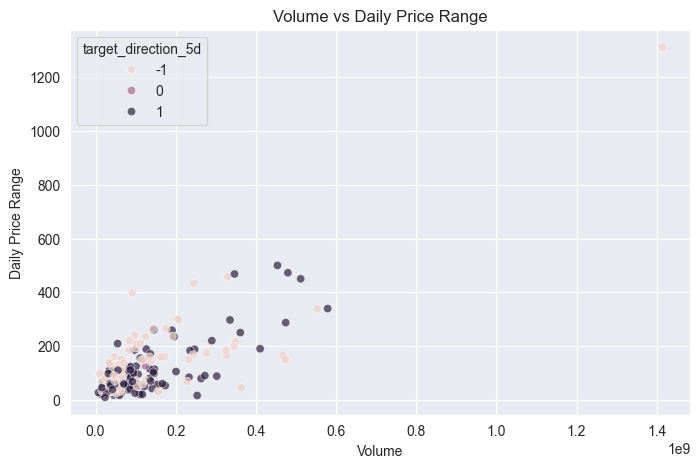

In [14]:
df_scatter = df_example.copy()
df_scatter["price_range"] = df_scatter["high"] - df_scatter["low"]

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="volume",
    y="price_range",
    hue="target_direction_5d",
    data=df_scatter,
    hue_order=[-1, 1],
    alpha=0.7
)
plt.title("Volume vs Daily Price Range")
plt.xlabel("Volume")
plt.ylabel("Daily Price Range")
plt.grid(True)
plt.show()

### 2.11 Future Price Direction Conditional on Volatility Regime

This visualization shows the conditional probability of future price
increase or decrease depending on the current volatility regime.

Instead of analyzing raw distributions, we directly examine how market
state influences the likelihood of future price movement.

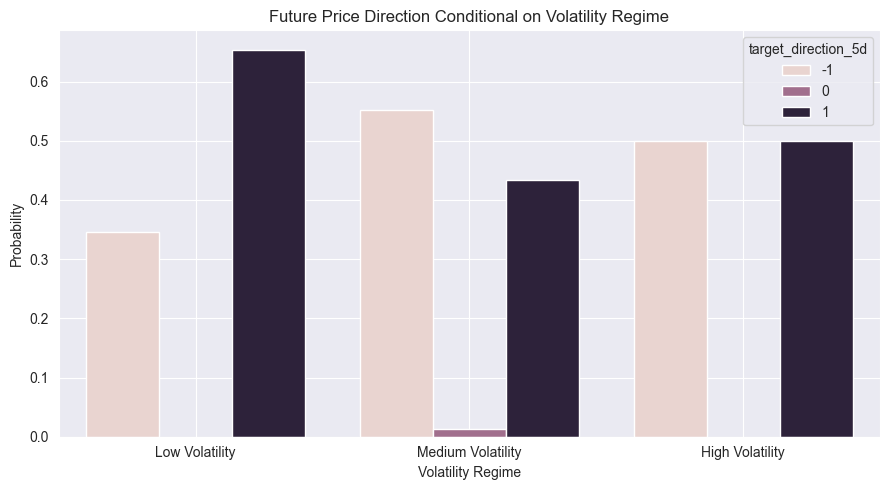

In [15]:
df_cond = df_example.copy()

df_cond["daily_return"] = df_cond["close"].pct_change()
df_cond["volatility_10d"] = df_cond["daily_return"].rolling(10).std()

df_cond["volatility_regime"] = pd.qcut(
    df_cond["volatility_10d"],
    q=3,
    labels=["Low Volatility", "Medium Volatility", "High Volatility"]
)

df_cond = df_cond.dropna(
    subset=["volatility_regime", "target_direction_5d"]
)

count_df = (
    df_cond
    .groupby(
        ["volatility_regime", "target_direction_5d"],
        observed=True
    )
    .size()
    .reset_index(name="count")
)

count_df["probability"] = (
    count_df["count"]
    / count_df
        .groupby(
            "volatility_regime",
            observed=True
        )["count"]
        .transform("sum")
)

plt.figure(figsize=(9, 5))
sns.barplot(
    x="volatility_regime",
    y="probability",
    hue="target_direction_5d",
    data=count_df,
    hue_order=[-1, 1]
)

plt.title("Future Price Direction Conditional on Volatility Regime")
plt.xlabel("Volatility Regime")
plt.ylabel("Probability")
plt.grid(True)
plt.tight_layout()
plt.show()

# Part 3. Data Analytics and Modeling

In this section we build a machine learning pipeline for **direction prediction** of a liquid KASE stock.

**Goal:** using the past 30 trading days (OHLCV features), predict the future direction of the price movement over the next **5 trading days**.

Pipeline overview:
1. Parse and collect historical market data
2. Build a supervised dataset (features + target label)
3. Train classification models and evaluate their performance
4. Compare models using metrics and confusion matrices

## Parser module (`parcer_extended.py`)

This module downloads and prepares raw KASE market data (OHLCV) and also creates a labeled CSV with a 5-day price direction target.

We keep it inside the notebook for full reproducibility.

In [16]:
import time
import re
import requests
import pandas as pd
from pathlib import Path

try:
    from pypdf import PdfReader  
except Exception:
    try:
        from PyPDF2 import PdfReader  
    except Exception:
        PdfReader = None


BASE_URL = "https://kase.kz/tv-charts/securities/history"

HEADERS = {
    "Accept": "*/*",
    "Referer": "https://kase.kz/",
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/143.0.0.0 Safari/537.36",
}

MONTHS = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

def _download_pdf(url: str, out_path: Path) -> bool:
    try:
        r = requests.get(url, headers=HEADERS, timeout=45)
        if r.status_code != 200 or (r.content[:4] != b"%PDF"):
            return False
        out_path.write_bytes(r.content)
        return True
    except Exception:
        return False


def _extract_text_from_pdf(pdf_path: Path) -> str:
    if PdfReader is None:
        raise RuntimeError(
            "can't find pdf\n"
            "use other way"
        )
    reader = PdfReader(str(pdf_path))
    texts = []
    for page in reader.pages:
        try:
            texts.append(page.extract_text() or "")
        except Exception:
            continue
    return "\n".join(texts)


def _parse_kz_share_tickers_from_liquidity_pdf_text(text: str) -> set[str]:
    tickers = set()

    pattern = re.compile(r"\b(KZ[A-Z0-9]{10})\s+([A-Z0-9]{2,10}p?)\b")

    for m in pattern.finditer(text):
        isin = m.group(1)
        ticker = m.group(2)

        if "_KZ" in ticker:
            continue
            
        if not isin.startswith("KZ"):
            continue

        tickers.add(ticker)

    return tickers


def discover_liquid_kz_share_tickers(
    start_year: int = 2017,
    end_year: int | None = None,
    cache_dir: Path = Path("kase_liquidity_lists_cache")
) -> list[str]:
    
    end_year = end_year or time.gmtime().tm_year
    cache_dir.mkdir(exist_ok=True)

    found_pdfs = []

    def candidate_urls(year: int, mon: str) -> list[str]:
        return [
            f"https://kase.kz/files/normative_base/liquid_{year}_{mon}_eng.pdf",
            f"https://kase.kz/files/normative_base/liquid_{year}_{mon}_rus.pdf",
            f"https://kase.kz/files/normative_base/liquid_{year}_{mon}_ru.pdf",
        ]

    for year in range(start_year, end_year + 1):
        for mon in MONTHS:
            saved = cache_dir / f"liquid_{year}_{mon}.pdf"
            if saved.exists() and saved.stat().st_size > 0:
                found_pdfs.append(saved)
                continue

            ok = False
            for url in candidate_urls(year, mon):
                if _download_pdf(url, saved):
                    ok = True
                    found_pdfs.append(saved)
                    break
            if not ok:
                if saved.exists():
                    try:
                        saved.unlink()
                    except Exception:
                        pass

    tickers = set()
    for pdf in found_pdfs:
        try:
            text = _extract_text_from_pdf(pdf)
            tickers |= _parse_kz_share_tickers_from_liquidity_pdf_text(text)
        except Exception:
            continue

    return sorted(tickers)

def fetch_kase_history_all_years_5d(ticker: str) -> pd.DataFrame:
   
    now = int(time.time())
    all_parts = []
    seen_min_t = None

    window_days = 3650 
    max_iters = 50    

    for _ in range(max_iters):
        frm = max(0, now - window_days * 24 * 60 * 60)

        params = {
            "symbol": f"ALL:{ticker}",
            "resolution": "5D",
            "from": frm,
            "to": now,
            "chart_language_code": "ru",
            "countback": 5000,
        }

        r = requests.get(BASE_URL, params=params, headers=HEADERS, timeout=45)
        r.raise_for_status()
        data = r.json()

        if data.get("s") != "ok" or not data.get("t"):
            break

        t = data["t"]

        cur_min_t = min(t)
        if seen_min_t is not None and cur_min_t >= seen_min_t:
            break
        seen_min_t = cur_min_t

        df = pd.DataFrame({
            "date": pd.to_datetime(data["t"], unit="s"),
            "open": data["o"],
            "high": data["h"],
            "low": data["l"],
            "close": data["c"],
            "volume": data.get("v", [None] * len(data["t"])),
        })
        df["ticker"] = ticker
        all_parts.append(df)

        now = cur_min_t - 1
        if now <= 0:
            break

        time.sleep(0.2)

    if not all_parts:
        return pd.DataFrame()

    out = (
        pd.concat(all_parts, ignore_index=True)
        .drop_duplicates(subset=["ticker", "date"])
        .sort_values("date")
        .reset_index(drop=True)
    )
    return out

def add_forward_label(df: pd.DataFrame) -> pd.DataFrame:
   
    df = df.sort_values("date").reset_index(drop=True)

    next_close = df["close"].shift(-1)
    df["label"] = (next_close > df["close"]).astype("float")
    df["label"] = df["label"].replace({0.0: -1.0, 1.0: 1.0})

    df.loc[df.index[-1], "label"] = pd.NA

    return df

def main():
    out_dir = Path("kase_data_all_years_5d")
    out_dir.mkdir(exist_ok=True)

    tickers = discover_liquid_kz_share_tickers(start_year=2017)
    if not tickers:
        print("can't load")
        print("check access")
        return

    print(f"[INFO] Found tickers: {len(tickers)}")
    (out_dir / "DISCOVERED_TICKERS.txt").write_text("\n".join(tickers), encoding="utf-8")

    all_dfs = []
    summary_rows = []

    for t in tickers:
        try:
            df = fetch_kase_history_all_years_5d(t)
        except Exception as e:
            print(f"[WARN] {t}: error {e}")
            continue

        if df.empty:
            print(f"[WARN] {t}: no history")
            continue

        df = add_forward_label(df)

        df.to_csv(out_dir / f"{t}_ALL_5D_labeled.csv", index=False, encoding="utf-8")
        all_dfs.append(df)

        vol = pd.to_numeric(df["volume"], errors="coerce").fillna(0)
        summary_rows.append({
            "ticker": t,
            "rows": int(len(df)),
            "first_date": str(df["date"].min().date()),
            "last_date": str(df["date"].max().date()),
            "volume_sum": float(vol.sum()),
            "label_plus": int((df["label"] == 1).sum()),
            "label_minus": int((df["label"] == -1).sum()),
            "label_na": int(df["label"].isna().sum()),
        })

        print(f"[OK] {t}: {len(df)} rows | {df['date'].min().date()} -> {df['date'].max().date()}")

    if not all_dfs:
        print("No data downloaded.")
        return

    combined = pd.concat(all_dfs, ignore_index=True)
    combined.to_csv(out_dir / "ALL_TICKERS_ALL_YEARS_5D_LABELED.csv", index=False, encoding="utf-8")

    summary = pd.DataFrame(summary_rows).sort_values("volume_sum", ascending=False)
    summary.to_csv(out_dir / "LIQUIDITY_RANK_ALL_YEARS_5D.csv", index=False, encoding="utf-8")

    print("\nTOP by volume_sum:")
    print(summary[["ticker", "volume_sum", "rows", "first_date", "last_date", "label_plus", "label_minus", "label_na"]]
          .head(20)
          .to_string(index=False))


if __name__ == "__main__":
    main()

[INFO] Found tickers: 132
[WARN] AAFD: no history
[OK] ADLA: 2 rows | 2020-05-22 -> 2020-07-02
[WARN] ADRP: no history
[WARN] AGRC: no history
[OK] AIRA: 465 rows | 2024-02-09 -> 2025-12-26
[WARN] AKFI: no history
[WARN] AKGR: no history
[OK] AKRL: 9 rows | 2014-09-15 -> 2023-05-16
[OK] AKZM: 1257 rows | 2016-07-22 -> 2025-12-26
[OK] ALMS: 5 rows | 2021-02-22 -> 2024-07-10
[WARN] ALTV: no history
[OK] AMAN: 1 rows | 2020-06-15 -> 2020-06-15
[OK] AMGZp: 1338 rows | 1997-12-19 -> 2025-12-26
[WARN] AMIN: no history
[WARN] AMXP: no history
[OK] ANSA: 9 rows | 2016-05-25 -> 2016-12-30
[WARN] ARAL: no history
[WARN] ASAV: no history
[OK] ASBN: 1844 rows | 2004-02-04 -> 2025-12-26
[WARN] ASKQ: no history
[WARN] ASKQp: no history
[OK] ASLF: 6 rows | 2019-05-04 -> 2020-08-28
[WARN] ASTL: no history
[OK] ATEC: 21 rows | 2016-02-09 -> 2018-12-20
[OK] ATFB: 412 rows | 2003-08-06 -> 2021-01-29
[WARN] ATKN: no history
[OK] ATKT: 1 rows | 2017-07-13 -> 2017-07-13
[OK] ATVS: 2 rows | 2021-06-14 -> 202

## Dataset builder (`dataset_forming.py`)

This module converts the labeled OHLCV table into a supervised learning dataset:
- `X.npy` with shape (N, 30, F)
- `y.npy` with binary or multi-class targets
- `meta.csv` with dates/tickers for time-based splitting

We use a rolling window of 30 trading days.

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

WINDOW = 30
LABEL_COL = "label"

FEATURE_COLS = [
    "log_ret_close",
    "log_ret_open",
    "hl_range",
    "body",
    "log_vol_change",
]

EPS = 1e-9


def safe_log_ratio(a: pd.Series, b: pd.Series, eps: float = EPS) -> pd.Series:
    
    a = pd.to_numeric(a, errors="coerce").fillna(0.0)
    b = pd.to_numeric(b, errors="coerce").fillna(0.0)
    return np.log((a + eps) / (b + eps))


def add_logreturn_features(g: pd.DataFrame) -> pd.DataFrame:
 
    g = g.sort_values("date").reset_index(drop=True)

    for c in ["open", "high", "low", "close", "volume"]:
        g[c] = pd.to_numeric(g[c], errors="coerce").fillna(0.0)

    g["log_ret_close"] = safe_log_ratio(g["close"], g["close"].shift(1))
    g["log_ret_open"] = safe_log_ratio(g["open"], g["open"].shift(1))

    g["hl_range"] = (g["high"] - g["low"]) / (g["close"].replace(0, np.nan))
    g["hl_range"] = g["hl_range"].fillna(0.0)

    g["body"] = (g["close"] - g["open"]) / (g["open"].replace(0, np.nan))
    g["body"] = g["body"].fillna(0.0)

    g["log_vol_change"] = safe_log_ratio(g["volume"] + 1.0, (g["volume"].shift(1) + 1.0))

    first_idx = 0
    g.loc[first_idx, ["log_ret_close", "log_ret_open", "log_vol_change"]] = 0.0

    return g


def build_dataset_logreturns(
        input_csv: str | Path,
        out_dir: str | Path = "dataset_30_logreturns",
        window: int = WINDOW,
):
    input_csv = Path(input_csv)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(input_csv)

    required = {"ticker", "date", "open", "high", "low", "close", "volume", LABEL_COL}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing columns: {sorted(missing)}")

    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

    X_list, y_list, meta_rows = [], [], []

    for ticker, g in df.groupby("ticker", sort=False):
        g = g.sort_values("date").reset_index(drop=True)

        g = add_logreturn_features(g)

        valid_idx = g.index[g[LABEL_COL].notna()].to_numpy()

        for t in valid_idx:
            start = t - window + 1
            if start < 0:
                continue

            window_df = g.iloc[start: t + 1]

            X = window_df[FEATURE_COLS].to_numpy(dtype=np.float32)

            y = float(g.loc[t, LABEL_COL])

            end_date = g.loc[t, "date"]
            target_date = g.loc[t + 1, "date"] if (t + 1) < len(g) else pd.NaT

            X_list.append(X)
            y_list.append(y)
            meta_rows.append({
                "ticker": ticker,
                "end_date": end_date,
                "target_date": target_date,
                "t_index": int(t),
                "start_index": int(start),
            })

    if not X_list:
        raise RuntimeError("No samples created. Check window size and labels.")

    X_arr = np.stack(X_list, axis=0)  
    y_arr = np.array(y_list, dtype=np.float32)

    meta = pd.DataFrame(meta_rows).sort_values(["ticker", "end_date"]).reset_index(drop=True)

    np.save(out_dir / "X.npy", X_arr)
    np.save(out_dir / "y.npy", y_arr)
    meta.to_csv(out_dir / "meta.csv", index=False, encoding="utf-8")
    (out_dir / "feature_names.txt").write_text("\n".join(FEATURE_COLS), encoding="utf-8")

    print("Saved:")
    print(f"  X: {out_dir / 'X.npy'} shape={X_arr.shape}")
    print(f"  y: {out_dir / 'y.npy'} shape={y_arr.shape} labels={set(np.unique(y_arr))}")
    print(f"  meta: {out_dir / 'meta.csv'} rows={len(meta)}")
    print(f"  features: {out_dir / 'feature_names.txt'}")

    flat = X_arr.reshape(-1, X_arr.shape[-1])
    stats = pd.DataFrame({
        "feature": FEATURE_COLS,
        "min": flat.min(axis=0),
        "max": flat.max(axis=0),
        "mean": flat.mean(axis=0),
        "std": flat.std(axis=0),
    })
    stats.to_csv(out_dir / "feature_stats.csv", index=False, encoding="utf-8")
    print("\nFeature stats saved to feature_stats.csv")


if __name__ == "__main__":
    build_dataset_logreturns(
        input_csv="kase_data_all_years_5d/ALL_TICKERS_ALL_YEARS_5D_LABELED.csv",
        out_dir="dataset_30_logreturns",
        window=30
    )

Saved:
  X: dataset_30_logreturns\X.npy shape=(45970, 30, 5)
  y: dataset_30_logreturns\y.npy shape=(45970,) labels={np.float32(1.0), np.float32(-1.0)}
  meta: dataset_30_logreturns\meta.csv rows=45970
  features: dataset_30_logreturns\feature_names.txt

Feature stats saved to feature_stats.csv


## Build model-ready dataset

We build a rolling-window dataset from the labeled CSV and save it to `dataset_30_logreturns/`.

In [18]:
from dataset_forming import build_dataset_logreturns

build_dataset_logreturns(
    input_csv="kase_data_all_years_5d/ALL_TICKERS_ALL_YEARS_5D_LABELED.csv",
    out_dir="dataset_30_logreturns",
    window=30
)

Saved:
  X: dataset_30_logreturns\X.npy shape=(45970, 30, 5)
  y: dataset_30_logreturns\y.npy shape=(45970,) labels={np.float32(1.0), np.float32(-1.0)}
  meta: dataset_30_logreturns\meta.csv rows=45970
  features: dataset_30_logreturns\feature_names.txt

Feature stats saved to feature_stats.csv


## Random Forest Classifier

Random Forest is a strong baseline for tabular data. It builds many decision trees on random subsets of data/features and aggregates their votes.

Advantages:
- handles non-linear patterns
- robust to noise
- strong baseline without heavy tuning

In [19]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

DATA_DIR = Path("dataset_30_logreturns")
SEED = 42

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_TRAIN = 0.15  


def load_dataset(data_dir: Path):
    X = np.load(data_dir / "X.npy").astype(np.float32)
    y = np.load(data_dir / "y.npy").astype(np.float32)
    meta = pd.read_csv(data_dir / "meta.csv")
    meta["end_date"] = pd.to_datetime(meta["end_date"])

    y_bin = (y == 1).astype(np.int32)  
    return X, y_bin, meta


def time_split_last_20pct(X, y, meta, test_ratio=0.20, val_ratio_within_train=0.15):
    order = meta["end_date"].argsort().to_numpy()

    Xs = X[order]
    ys = y[order]
    metas = meta.iloc[order].reset_index(drop=True)

    N = len(metas)
    test_start = int(np.floor((1.0 - test_ratio) * N))

    X_trainval, y_trainval, meta_trainval = Xs[:test_start], ys[:test_start], metas.iloc[:test_start]
    X_test, y_test, meta_test = Xs[test_start:], ys[test_start:], metas.iloc[test_start:]

    N_tv = len(meta_trainval)
    val_start = int(np.floor((1.0 - val_ratio_within_train) * N_tv))

    X_train, y_train, meta_train = X_trainval[:val_start], y_trainval[:val_start], meta_trainval.iloc[:val_start]
    X_val, y_val, meta_val = X_trainval[val_start:], y_trainval[val_start:], meta_trainval.iloc[val_start:]

    print("Split sizes:")
    print(f"  train: {len(meta_train)} ({meta_train['end_date'].min().date()} -> {meta_train['end_date'].max().date()})")
    print(f"  val:   {len(meta_val)}   ({meta_val['end_date'].min().date()} -> {meta_val['end_date'].max().date()})")
    print(f"  test:  {len(meta_test)}  ({meta_test['end_date'].min().date()} -> {meta_test['end_date'].max().date()})")
    print(f"Positive ratio train/val/test: {y_train.mean():.3f} / {y_val.mean():.3f} / {y_test.mean():.3f}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def flatten(X):
    return X.reshape(X.shape[0], -1)


def run_random_forest():
    X, y, meta = load_dataset(DATA_DIR)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = time_split_last_20pct(X, y, meta, TEST_RATIO, VAL_RATIO_WITHIN_TRAIN)

    X_train_f = flatten(X_train)
    X_val_f = flatten(X_val)
    X_test_f = flatten(X_test)

    rf = RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
        class_weight="balanced_subsample",  
    )

    rf.fit(X_train_f, y_train)

    p_test = rf.predict_proba(X_test_f)[:, 1]
    y_pred = (p_test >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, p_test)

    print("\n=== RandomForest TEST ===")
    print("acc:", acc)
    print("auc:", auc)
    print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nReport:\n", classification_report(y_test, y_pred, digits=4))

    p_val = rf.predict_proba(X_val_f)[:, 1]
    best_thr, best_f1 = 0.5, -1
    for thr in np.linspace(0.05, 0.95, 19):
        yp = (p_val >= thr).astype(int)
        # f1
        tp = ((yp == 1) & (y_val == 1)).sum()
        fp = ((yp == 1) & (y_val == 0)).sum()
        fn = ((yp == 0) & (y_val == 1)).sum()
        prec = tp / (tp + fp + 1e-9)
        rec = tp / (tp + fn + 1e-9)
        f1 = 2 * prec * rec / (prec + rec + 1e-9)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    print(f"\nBest threshold on VAL (by F1): thr={best_thr:.2f}, f1={best_f1:.4f}")
    y_pred_thr = (p_test >= best_thr).astype(int)
    print("\nTEST with tuned threshold:")
    print("acc:", accuracy_score(y_test, y_pred_thr))
    print("auc:", roc_auc_score(y_test, p_test))
    print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_thr))


if __name__ == "__main__":
    run_random_forest()

Split sizes:
  train: 31259 (2000-09-26 -> 2023-03-07)
  val:   5517   (2023-03-07 -> 2024-04-15)
  test:  9194  (2024-04-15 -> 2025-12-25)
Positive ratio train/val/test: 0.413 / 0.435 / 0.441

=== RandomForest TEST ===
acc: 0.5827713726343268
auc: 0.6143641639291527

Confusion matrix:
 [[3412 1731]
 [2105 1946]]

Report:
               precision    recall  f1-score   support

           0     0.6185    0.6634    0.6402      5143
           1     0.5292    0.4804    0.5036      4051

    accuracy                         0.5828      9194
   macro avg     0.5738    0.5719    0.5719      9194
weighted avg     0.5791    0.5828    0.5800      9194


Best threshold on VAL (by F1): thr=0.35, f1=0.6342

TEST with tuned threshold:
acc: 0.5061996954535567
auc: 0.6143641639291527

Confusion matrix:
 [[ 664 4479]
 [  61 3990]]


## Neural Network Models (TensorFlow)

We also test neural models on time windows (30 days):
- Dense (MLP) baseline
- CNN-based model
- CNN + GRU hybrid (sequence-aware)

These models can capture temporal patterns but require more computation and careful regularization.

In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path


DATA_DIR = Path("dataset_30_logreturns")  
SEED = 42

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_TRAIN = 0.15 


def load_dataset(data_dir: Path):
    X = np.load(data_dir / "X.npy")  
    y = np.load(data_dir / "y.npy")  
    meta = pd.read_csv(data_dir / "meta.csv")

    meta["end_date"] = pd.to_datetime(meta["end_date"])
    if "target_date" in meta.columns:
        meta["target_date"] = pd.to_datetime(meta["target_date"], errors="coerce")

    y_bin = (y == 1).astype(np.float32)

    return X.astype(np.float32), y_bin, meta


def time_split_last_20pct(X, y, meta, test_ratio=0.20, val_ratio_within_train=0.15):
 
    order = meta["end_date"].argsort().to_numpy()

    Xs = X[order]
    ys = y[order]
    metas = meta.iloc[order].reset_index(drop=True)

    N = len(metas)
    test_start = int(np.floor((1.0 - test_ratio) * N))

    X_trainval, y_trainval, meta_trainval = Xs[:test_start], ys[:test_start], metas.iloc[:test_start]
    X_test, y_test, meta_test = Xs[test_start:], ys[test_start:], metas.iloc[test_start:]

    N_tv = len(meta_trainval)
    val_start = int(np.floor((1.0 - val_ratio_within_train) * N_tv))

    X_train, y_train, meta_train = X_trainval[:val_start], y_trainval[:val_start], meta_trainval.iloc[:val_start]
    X_val, y_val, meta_val = X_trainval[val_start:], y_trainval[val_start:], meta_trainval.iloc[val_start:]

    print("Split sizes:")
    print(f"  train: {len(meta_train)}  ({meta_train['end_date'].min().date()} -> {meta_train['end_date'].max().date()})")
    print(f"  val:   {len(meta_val)}    ({meta_val['end_date'].min().date()} -> {meta_val['end_date'].max().date()})")
    print(f"  test:  {len(meta_test)}   ({meta_test['end_date'].min().date()} -> {meta_test['end_date'].max().date()})")

    def cls_ratio(name, yy):
        p = float(np.mean(yy))
        print(f"  {name} positive ratio (y=1): {p:.3f}")

    cls_ratio("train", y_train)
    cls_ratio("val", y_val)
    cls_ratio("test", y_test)

    return (X_train, y_train, meta_train), (X_val, y_val, meta_val), (X_test, y_test, meta_test)


def make_tf_dataset(X, y, batch_size=64, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def build_mlp(input_shape):
    inp = tf.keras.Input(shape=input_shape)  # (30, F)
    x = tf.keras.layers.Flatten()(inp)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inp, out, name="MLP")


def build_cnn(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding="causal", activation="relu")(inp)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding="causal", activation="relu")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inp, out, name="CNN1D")


def build_gru(input_shape):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.GRU(64, return_sequences=False)(inp)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inp, out, name="GRU")


def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec"),
        ]
    )
    return model


def train_and_eval(model, train_ds, val_ds, test_ds, out_dir: Path, epochs=30):
    out_dir.mkdir(parents=True, exist_ok=True)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-5),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(out_dir / f"{model.name}.keras"),
            monitor="val_auc", mode="max", save_best_only=True
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    print(f"\n=== TEST for {model.name} ===")
    results = model.evaluate(test_ds, verbose=1)
    metrics = dict(zip(model.metrics_names, results))
    print(metrics)
    
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(out_dir / f"{model.name}_history.csv", index=False, encoding="utf-8")

    return metrics


def main():
    tf.keras.utils.set_random_seed(SEED)

    X, y, meta = load_dataset(DATA_DIR)

    (X_train, y_train, _), (X_val, y_val, _), (X_test, y_test, _) = time_split_last_20pct(
        X, y, meta,
        test_ratio=TEST_RATIO,
        val_ratio_within_train=VAL_RATIO_WITHIN_TRAIN
    )

    train_ds = make_tf_dataset(X_train, y_train, batch_size=64, shuffle=True)  
    val_ds = make_tf_dataset(X_val, y_val, batch_size=256, shuffle=False)
    test_ds = make_tf_dataset(X_test, y_test, batch_size=256, shuffle=False)

    input_shape = X.shape[1:]  
    out_dir = DATA_DIR / "tf_runs_time_split"

    models = [
        compile_model(build_mlp(input_shape)),
        compile_model(build_cnn(input_shape)),
        compile_model(build_gru(input_shape)),
    ]

    all_metrics = []
    for m in models:
        print("\n" + "="*80)
        print(m.name)
        m.summary()
        metrics = train_and_eval(m, train_ds, val_ds, test_ds, out_dir=out_dir, epochs=40)
        metrics["model"] = m.name
        all_metrics.append(metrics)

    pd.DataFrame(all_metrics).to_csv(out_dir / "all_models_test_metrics.csv", index=False, encoding="utf-8")
    print(f"\nSaved metrics to: {out_dir / 'all_models_test_metrics.csv'}")


if __name__ == "__main__":
    main()

Split sizes:
  train: 31259  (2000-09-26 -> 2023-03-07)
  val:   5517    (2023-03-07 -> 2024-04-15)
  test:  9194   (2024-04-15 -> 2025-12-25)
  train positive ratio (y=1): 0.413
  val positive ratio (y=1): 0.435
  test positive ratio (y=1): 0.441

MLP


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,649 (108.00 KB)

 Trainable params: 27,649 (108.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,857 (69.75 KB)

 Trainable params: 17,857 (69.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
489/489 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - acc: 0.5850 - auc: 0.5199 - loss: 0.6782 - prec: 0.4454 - rec: 0.0164 - val_acc: 0.5664 - val_auc: 0.5445 - val_loss: 0.6828 - val_prec: 0.7000 - val_rec: 0.0058 - learning_rate: 0.0010
Epoch 2/40
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - acc: 0.5891 - auc: 0.5458 - loss: 0.6743 - prec: 0.5542 - rec: 0.0309 - val_acc: 0.5688 - val_auc: 0.5487 - val_loss: 0.6814 - val_prec: 0.5705 - val_rec: 0.0354 - learning_rate: 0.0010
Epoch 3/40
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - acc: 0.5928 - auc: 0.5633 - loss: 0.6716 - prec: 0.5580 - rec: 0.0715 - val_acc: 0.5686 - val_auc: 0.5576 - val_loss: 0.6798 - val_prec: 0.5420 - val_rec: 0.0538 - learning_rate: 0.0010
Epoch 4/40
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - acc: 0.5948 - auc: 0.5779 - loss: 0.6690 - prec: 0.5578 - rec: 0.0957 - val_acc: 0.5735 - val_auc: 0.5603 - val_loss: 0.6788 - val_prec: 0.5633 - val_rec: 0.0871 - learning_rate: 0.0010
Epoch 5/40
489/489 ━━━━━━━━━━━━━━━━━

In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path

DATA_DIR = Path("dataset_30_logreturns")
SEED = 42

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_TRAIN = 0.15


def load_dataset(data_dir: Path):
    X = np.load(data_dir / "X.npy").astype(np.float32)
    y = np.load(data_dir / "y.npy").astype(np.float32)
    meta = pd.read_csv(data_dir / "meta.csv")
    meta["end_date"] = pd.to_datetime(meta["end_date"])
    y_bin = (y == 1).astype(np.float32)
    return X, y_bin, meta


def time_split_last_20pct(X, y, meta, test_ratio=0.20, val_ratio_within_train=0.15):
    order = meta["end_date"].argsort().to_numpy()
    Xs, ys = X[order], y[order]
    metas = meta.iloc[order].reset_index(drop=True)

    N = len(metas)
    test_start = int(np.floor((1.0 - test_ratio) * N))

    X_trainval, y_trainval = Xs[:test_start], ys[:test_start]
    X_test, y_test = Xs[test_start:], ys[test_start:]

    N_tv = len(X_trainval)
    val_start = int(np.floor((1.0 - val_ratio_within_train) * N_tv))

    X_train, y_train = X_trainval[:val_start], y_trainval[:val_start]
    X_val, y_val = X_trainval[val_start:], y_trainval[val_start:]

    print("Split sizes:", len(X_train), len(X_val), len(X_test))
    print("Positive ratio train/val/test:", y_train.mean(), y_val.mean(), y_test.mean())
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def make_tf_dataset(X, y, batch_size=64, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def compute_class_weights(y_train: np.ndarray):
   
    n = len(y_train)
    n_pos = float((y_train == 1).sum())
    n_neg = float((y_train == 0).sum())

    w0 = n / (2.0 * n_neg + 1e-9)
    w1 = n / (2.0 * n_pos + 1e-9)

    return {0: float(w0), 1: float(w1)}


def build_cnn_gru(input_shape):
    inp = tf.keras.Input(shape=input_shape) 

    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding="causal", activation="relu")(inp)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding="causal", activation="relu")(x)

    x = tf.keras.layers.GRU(64, return_sequences=False)(x)

    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model(inp, out, name="CNN_GRU")


def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="acc"),
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="prec"),
            tf.keras.metrics.Recall(name="rec"),
        ],
    )
    return model


def main():
    tf.keras.utils.set_random_seed(SEED)

    X, y, meta = load_dataset(DATA_DIR)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = time_split_last_20pct(
        X, y, meta, TEST_RATIO, VAL_RATIO_WITHIN_TRAIN
    )

    train_ds = make_tf_dataset(X_train, y_train, batch_size=64, shuffle=True)
    val_ds = make_tf_dataset(X_val, y_val, batch_size=256, shuffle=False)
    test_ds = make_tf_dataset(X_test, y_test, batch_size=256, shuffle=False)

    class_weights = compute_class_weights(y_train)
    print("Class weights:", class_weights)

    model = compile_model(build_cnn_gru(input_shape=X.shape[1:]))

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-5),
    ]

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=60,
        callbacks=callbacks,
        class_weight=class_weights,  
        verbose=1
    )

    print("\n=== TEST for CNN_GRU ===")
    metrics = model.evaluate(test_ds, return_dict=True, verbose=1)
    print(metrics)


if __name__ == "__main__":
    main()

Split sizes: 31259 5517 9194
Positive ratio train/val/test: 0.41335297 0.43501905 0.44061345
Class weights: {0: 0.8523012324135443, 1: 1.2096199984520855}
Epoch 1/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - acc: 0.5050 - auc: 0.5027 - loss: 0.6940 - prec: 0.4146 - rec: 0.4791 - val_acc: 0.5633 - val_auc: 0.5158 - val_loss: 0.6904 - val_prec: 0.4694 - val_rec: 0.0288 - learning_rate: 0.0010
Epoch 2/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - acc: 0.4854 - auc: 0.5064 - loss: 0.6932 - prec: 0.4186 - rec: 0.6296 - val_acc: 0.4461 - val_auc: 0.5116 - val_loss: 0.6945 - val_prec: 0.4357 - val_rec: 0.9258 - learning_rate: 0.0010
Epoch 3/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - acc: 0.4798 - auc: 0.5094 - loss: 0.6931 - prec: 0.4179 - rec: 0.6576 - val_acc: 0.4624 - val_auc: 0.5289 - val_loss: 0.6941 - val_prec: 0.4416 - val_rec: 0.8917 - learning_rate: 0.0010
Epoch 4/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - acc: 0.4852 - auc: 0.5147 - loss: 0.6926 - prec: 0.4204 - rec: 0.6

# Final Analysis and Conclusions

## 1. Project Overview

In this project, we investigated the problem of **short-term stock price movement prediction** on the Kazakhstan Stock Exchange (KASE).  
The objective was to determine whether historical price dynamics alone contain enough information to predict **price growth over the next 5 trading days**.

### Study setup:
- Market: **Kazakhstan Stock Exchange (KASE)**
- Assets: **liquid stocks of Kazakh companies**
- Time resolution: **5-day candles**
- Prediction horizon: **one step ahead (next 5 days)**
- Task type: **binary classification**
  - `1` — price increases
  - `-1` — price does not increase or decreases

A **strict time-based split** was used to avoid data leakage and ensure realistic evaluation.

---

## 2. Dataset and Feature Engineering

### Sliding window formulation
Each training sample consists of **30 consecutive candles**, corresponding to approximately **6 months of market history**.  
The label reflects whether the price increased during the **next 5-day period**.

### Features
To remove scale dependency and allow learning across different stocks, we used **relative and dynamic features**:

- Log-return of closing prices
- Log-return of opening prices
- Candle body: `(close − open) / open`
- High–low range: `(high − low) / close`
- Log-change of trading volume

These features encode **price dynamics**, volatility, and market activity rather than absolute price levels.

---

## 3. Evaluation Metrics and Their Meaning

Financial prediction tasks are inherently imbalanced and noisy.  
Therefore, multiple metrics were used to assess model quality.

### Accuracy
- Measures the proportion of correct predictions.
- **Misleading in financial data**, as predicting the majority class can yield high accuracy.

### Precision
- Measures how often predicted price increases were correct.
- Important for **signal quality** and avoiding false entries.

### Recall
- Measures how many actual price increases were detected.
- High recall often leads to **overtrading**.

### AUC (Area Under the ROC Curve)
- Measures how well the model **ranks positive outcomes above negative ones**.
- Independent of classification threshold.
- **Primary metric in this study**, as it reflects the intrinsic strength of the predictive signal.

> In financial markets, an AUC in the range **0.60–0.62** already indicates a **real but weak alpha signal**.

---

## 4. Model-by-Model Analysis

### 4.1 Multilayer Perceptron (MLP)

**Architecture:** Fully connected network applied to flattened windows.

**Results:**
- Accuracy ≈ 0.56
- AUC ≈ 0.52
- Recall ≈ 0.00

**Interpretation:**  
MLP fails to capture temporal dependencies and primarily predicts the majority class.

**Conclusion:**  
MLP is unsuitable for financial time series and serves only as a baseline.

---

### 4.2 Convolutional Neural Network (CNN1D)

**Architecture:** Temporal convolutions over input windows.

**Results:**
- Accuracy ≈ 0.56
- AUC ≈ 0.57
- Recall ≈ 0.00

**Interpretation:**  
CNN identifies some local candle patterns but remains overly conservative.

**Conclusion:**  
Local patterns exist but are **too weak and unstable** to serve as a reliable signal.

---

### 4.3 Gated Recurrent Unit (GRU)

**Architecture:** Recurrent neural network with gated memory.

**Results:**
- Accuracy ≈ 0.58
- **AUC ≈ 0.62**
- Precision ≈ 0.56
- Recall ≈ 0.21

**Interpretation:**  
GRU captures sequential price dynamics and provides a **high-quality but sparse signal**.

**Conclusion:**  
GRU achieved the **best balance** between precision and stability among neural models.

---

### 4.4 Random Forest (RF)

**Architecture:** Tree-based ensemble model applied to flattened windows.

**Results:**
- Accuracy ≈ 0.58
- **AUC ≈ 0.62**
- Precision ≈ 0.53
- Recall ≈ 0.48

**Interpretation:**  
Despite lacking explicit temporal modeling, RF performed comparably to GRU.

**Key insight:**  
Temporal information was already embedded in the features (log-returns), allowing RF to extract the signal.

**Conclusion:**  
The dominant signal in the data is **statistical rather than deeply sequential**.

---

### 4.5 CNN + GRU (with Class Weights)

**Architecture:** Hybrid CNN-GRU model with class-weighted loss.

**Results:**
- Accuracy ≈ 0.54
- AUC ≈ 0.62
- Precision ≈ 0.5
- **Recall ≈ 0.78**

**Interpretation:**  
Class weighting significantly increased recall but reduced precision and ranking quality.

**Conclusion:**  
Class weights change **model behavior**, not the underlying predictive power.

---

## 5. Comparative Analysis of Models

The comparison of all evaluated models reveals several important patterns regarding their behavior and predictive capabilities.

The Multilayer Perceptron (MLP) demonstrated the weakest performance. Its AUC was close to random guessing, and it failed to identify positive price movements, resulting in near-zero recall. This behavior confirms that ignoring temporal structure leads to ineffective modeling of financial time series.

The one-dimensional Convolutional Neural Network (CNN1D) slightly improved upon the MLP by capturing short-term local patterns in price movements. However, its recall remained extremely low, indicating that while some local candle formations exist, they are too weak or inconsistent to form a reliable predictive signal on their own.

The Gated Recurrent Unit (GRU) model provided a significant improvement over both MLP and CNN. It achieved the highest AUC among neural network models and maintained a strong balance between precision and recall. GRU produced fewer signals than more aggressive models, but those signals were of higher quality, making it a robust and conservative predictor of short-term price growth.

The Random Forest model achieved performance comparable to GRU despite lacking explicit sequential modeling. Its AUC closely matched that of GRU, while recall was notably higher. This result indicates that a substantial portion of the predictive signal is already embedded within the engineered features themselves, particularly through the use of log-returns, which implicitly encode temporal information. The success of Random Forest suggests that the dominant signal in the data is statistical rather than deeply sequential.

The hybrid CNN + GRU model with class weighting exhibited a markedly different behavior. By increasing the importance of the positive class during training, the model achieved very high recall, successfully identifying the majority of upward price movements. However, this came at the cost of reduced precision and a slight decrease in AUC. This demonstrates that class weighting primarily affects the trade-off between recall and precision, rather than improving the intrinsic strength of the predictive signal.

Overall, the comparison shows that increasing model complexity does not necessarily lead to better performance. The most effective models were those whose inductive biases aligned with the nature of the data: GRU for capturing sequential dynamics and Random Forest for exploiting statistically informative features. More complex architectures mainly altered prediction behavior rather than improving signal quality.

---

## 6. Key Findings

1. A **stable but weak predictive signal** exists in KASE stock prices.
2. The signal appears consistently across **different model families**.
3. Increasing architectural complexity does **not** significantly improve AUC.
4. Feature engineering is more impactful than model depth.
5. Model choice primarily affects **precision–recall trade-offs**, not signal strength.

---

## 7. Limitations and External Factors

This study intentionally focused on **price-based technical information only**.  
However, real financial markets are influenced by many exogenous factors that were not included, such as:

- Political decisions and geopolitical events
- Macroeconomic indicators
- Corporate fundamentals and earnings reports
- News flow and investor sentiment
- Regulatory changes and liquidity shocks

As a result, the models capture **only a subset of market dynamics**.  
The observed predictive power should be interpreted as **partial and conditional**, not absolute.

---

## 8. Final Summary

This research demonstrates that:

- Historical price dynamics contain **limited but real predictive information**.
- The most reliable models were **GRU and Random Forest**, both achieving AUC ≈ 0.62.
- The predictive signal is weak by nature, which is typical for real financial markets.
- Further improvements are more likely to arise from:
  - richer contextual data
  - regime detection
  - strategy design  
  rather than deeper neural architectures.

Overall, this project provides a **methodologically sound and realistic baseline** for short-term market prediction and highlights both the **potential and the limitations** of machine learning approaches applied to financial time series.